<a href="https://colab.research.google.com/github/estefaniaperezpadilla/Estadistica2026B/blob/main/Proyecto_Seguros__Medicos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
1# repositorios: www.github.com
# bases de datos: www.kaggle.com

link = "https://raw.githubusercontent.com/estefaniaperezpadilla/Estadistica2026B/refs/heads/main/Seguro%20Medicos/%20Radme_text.csv"

import pandas as pd

df = pd.read_csv(link)

df

,edad,sexo,imc,niñas,fumador,región,cargos
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   edad     1338 non-null   int64  
 1   sexo     1338 non-null   object 
 2   imc      1338 non-null   float64
 3   niñas    1338 non-null   int64  
 4   fumador  1338 non-null   object 
 5   región   1338 non-null   object 
 6   cargos   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.dropna(inplace = True)

In [6]:
df.describe()

,edad,imc,niñas,cargos
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
x = df["imc"]
y = df["cargos"]

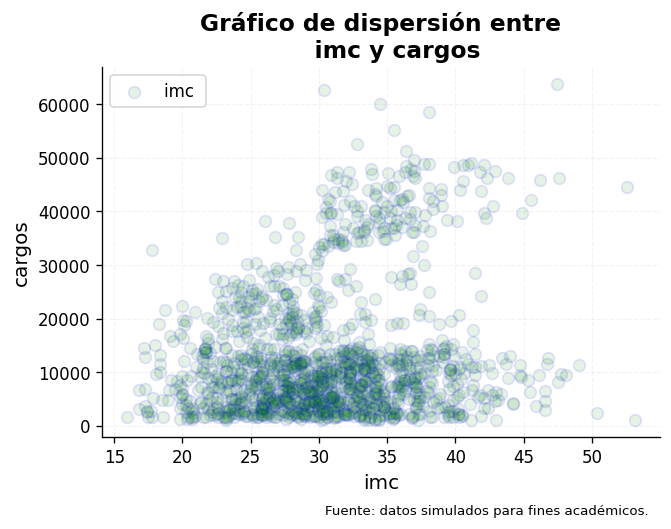

In [8]:
# @title
# 2. Realice un diagrama de dispersión para estos datos.
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='green',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.1,            # transparencia
    s=50,                 # tamaño de los puntos
    label='imc ' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
# plt.plot(
#     x, y,
#     color='orange',   # color de la línea
#     linewidth=2.2,        # grosor de la línea
#     linestyle='-',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=5,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Datos observados'
# )

# --- Título ---
plt.title(
    '''Gráfico de dispersión entre
    imc y cargos''',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'imc',
    fontsize=12
)

plt.ylabel(
    'cargos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    'Fuente: datos simulados para fines académicos.',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()


In [9]:
#4. Calcule el coeficiente de correlación e interprete el resultado.
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.1983
Valor p:  0.0000


In [10]:
# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el
# gráfico de dispersión

import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,1192.937209
imc,393.873031


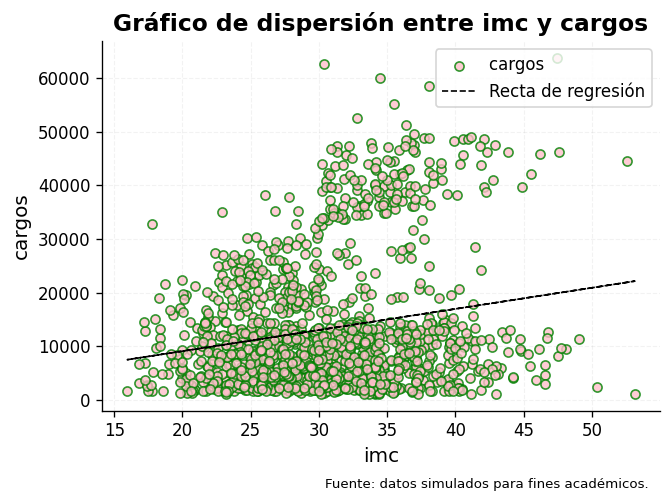

In [27]:
# @title
# 2. Realice un diagrama de dispersión para estos datos.
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='pink',     # color de los puntos
    edgecolor='green',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='cargos ' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Gráfico de dispersión entre imc y cargos',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'imc',
    fontsize=12
)

plt.ylabel(
    'cargos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    'Fuente: datos simulados para fines académicos.',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()


In [12]:
# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  3.93%



In [13]:
modelo.params

,0
const,1192.937209
imc,393.873031


In [14]:
# 7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
# regresión ajustada ( b1 )

# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-2072.974250,4458.848668
imc,289.408862,498.337199


In [15]:
# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?

# Los residuales son la diferencia entre el valor real y el valor que da el
# modelo

# residuales = y - y_calculada
residuales = modelo.resid

residuales

,0
0,4702.929232
1,-12768.477159
2,-9741.285225
3,11848.646237
4,-8701.135138
...,...
1333,-2790.636673
1334,-11559.383552
1335,-14077.324894
1336,-9346.916404


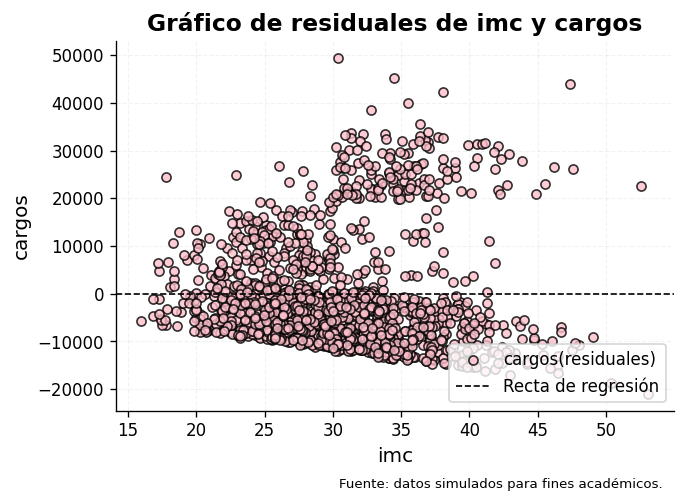

In [28]:
# @title
# 2. Realice un diagrama de dispersión para estos datos.
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuales,
    marker="o",       # forma
    color='pink',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='cargos(residuales)' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Gráfico de línea ---
# plt.plot(
#     x, y_calculada,
#     color='black',   # color de la línea
#     linewidth=1.0,        # grosor de la línea
#     linestyle='--',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=0,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Recta de regresión'
# )

# --- Título ---
plt.title(
    'Gráfico de residuales de imc y cargos',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'imc',
    fontsize=12
)

plt.ylabel(
    'cargos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    'Fuente: datos simulados para fines académicos.',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()


In [17]:
# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.

# Test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad
# alpha = 0.05

from scipy.stats import shapiro

_, valor_p = shapiro(residuales)

print(f"Valor-p: {valor_p: 0.4f}")

Valor-p:  0.0000


valor-p (Shapiro) = 1.0130687980336073e-32


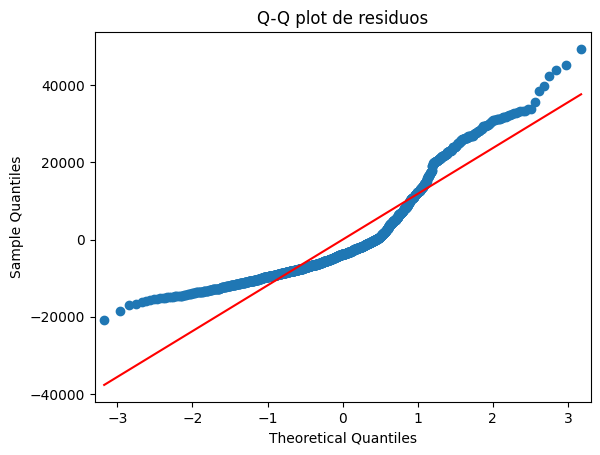

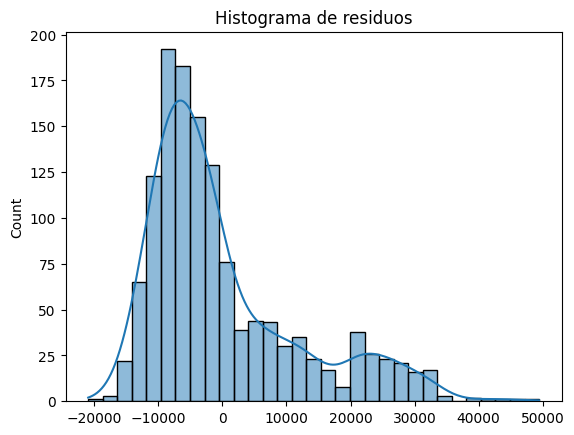

In [18]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [19]:
# 10. Realice la prueba de Breusch-Pagan para los residuales
# y comente el resultado.

# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.0000



In [20]:
df.describe()

,edad,imc,niñas,cargos
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [21]:
# para intrepolado
modelo.predict([1, 2])

array([1980.68327056])

In [22]:
df

,edad,sexo,imc,niñas,fumador,región,cargos
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [23]:
#11 para extrapolar
modelo.predict([1,6])

array([3556.17539375])

In [24]:
modelo.params

,0
const,1192.937209
imc,393.873031


In [29]:
# 12. Realice una tabla ANOVA e interprete el resultado.

# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('imc ~ cargos ', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
cargos,1.0,1955.949920,1955.949920,54.709308,2.459086e-13
Residual,1336.0,47764.250467,35.751684,NaN,NaN
